## Notebook 13 – Statistical Data Visualization

### Installing the Libraries
I am installing numpy and pandas to create and handle the data, matplotlib for the basic charts, and seaborn for the statistical charts like violin plot, pair plot and heatmap, which take much less code in seaborn than in matplotlib.

In [1]:
!pip install numpy pandas matplotlib seaborn

### Importing the Libraries

In [2]:
import numpy as np               # to generate the numeric data
import pandas as pd              # to store the data in a table (DataFrame)
import matplotlib.pyplot as plt  # for the basic charts
import seaborn as sns            # for the statistical charts

# keeping all charts at a similar size so they look consistent
plt.rcParams["figure.figsize"] = (6, 4)

### Sample Dataset
Instead of making a new small list for every chart, I created one student dataset and I will reuse it for all the visualizations below. It has 200 students with study hours, attendance, marks, age, gender and department. The data is generated using a fixed seed, so it gives the same values every time the notebook is run.

The only exception is the Line Chart, which needs something that changes over time, so that topic uses a small monthly sales series.

In [4]:
np.random.seed(42)
n = 200

study_hours = np.clip(np.random.normal(5, 1.5, n), 0.5, 10).round(1)
attendance = np.clip(60 + study_hours * 4 + np.random.normal(0, 6, n), 50, 100).round(1)
marks = np.clip(25 + study_hours * 7 + np.random.normal(0, 8, n), 0, 100).round(1)
age = np.random.randint(18, 25, n)
gender = np.random.choice(["Male", "Female"], n)
department = np.random.choice(["CSE", "ECE", "Mechanical", "Civil"], n)

df = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "marks": marks,
    "age": age,
    "gender": gender,
    "department": department
})

df.head()

,study_hours,attendance,marks,age,gender,department
0,5.7,84.9,52.1,24,Male,Mechanical
1,4.8,82.6,53.8,21,Female,Mechanical
2,6.0,90.5,67.0,21,Female,ECE
3,7.3,95.5,76.5,22,Female,CSE
4,4.6,70.1,53.6,19,Female,Civil


**What this does:** It creates 200 students. Attendance and marks are made to depend on study hours (plus some random noise), so the dataset has realistic relationships to show in the charts. Age, gender and department are random and have no real effect on marks.

In [5]:
print("Shape of dataset:", df.shape)
print(df.describe().round(2))

Shape of dataset: (200, 6)
       study_hours  attendance   marks     age
count       200.00      200.00  200.00  200.00
mean          4.94       80.21   58.86   20.99
std           1.40        8.40   11.75    2.07
min           1.10       53.80   28.70   18.00
25%           3.90       74.35   49.90   19.00
50%           5.00       80.55   59.20   21.00
75%           5.72       85.93   66.00   23.00
max           9.10      100.00   97.90   24.00


**What this does:** `describe()` gives the count, mean, standard deviation, min, quartiles and max of every numeric column. The average marks are around 59 with a standard deviation of about 12, which is useful to remember while reading the charts below.

## Histogram

### Purpose
A histogram shows how the values of one numeric variable are distributed, by grouping the values into bins and counting how many fall into each bin. It answers the question: what does the shape of this data look like?

### When to Use
Use it when you want to see the distribution of a single continuous variable, like marks, income or age, and check whether it is symmetric, skewed or has more than one peak.

### Python Example

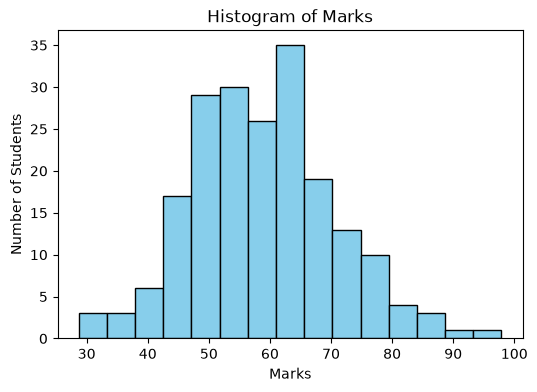

In [6]:
plt.hist(df["marks"], bins=15, color="skyblue", edgecolor="black")
plt.title("Histogram of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()

#### What the program does
The program splits the range of marks into 15 equal bins and draws a bar for each bin, where the height of the bar is the number of students whose marks fall in that bin.

### Interpretation
The bars are tallest in the middle (roughly 47 to 66 marks) and get shorter toward both ends, so the shape is roughly bell-shaped. This happens because marks were built from study hours that are themselves normally distributed around 5 hours, so most students are near the average and only a few score very low or very high. There is a slight tail toward the higher marks, which matches the small positive skew in the data.

#### Advantages
- Shows the shape of the distribution at a glance (symmetric, skewed, multiple peaks).
- Easy to read and works with large datasets.

#### Limitations
- The shape can change depending on the number of bins chosen.
- Only shows one variable at a time and hides the individual data points.

## Bar Chart

### Purpose
A bar chart compares a value across different categories, using the height of each bar to represent the value. Unlike a histogram, the bars here are separate categories, not ranges of a number.

### When to Use
Use it when comparing categories, like average marks by department, sales by region, or count of customers by plan.

### Python Example

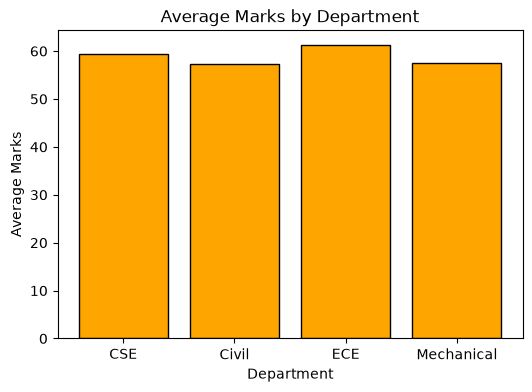

In [7]:
avg_marks = df.groupby("department")["marks"].mean()

plt.bar(avg_marks.index, avg_marks.values, color="orange", edgecolor="black")
plt.title("Average Marks by Department")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

#### What the program does
The program groups the students by department, calculates the average marks of each group, and draws one bar per department.

### Interpretation
All four bars are very close in height, with ECE slightly higher (around 61) and Civil and Mechanical slightly lower (around 57). This is because department was assigned randomly in the dataset and has no real effect on marks, so the differences are just random variation. The bars also start from zero, which makes small differences look even smaller, so this chart tells us that department is not a strong factor for marks here.

#### Advantages
- Very easy to read and compare across categories.
- Works well for both counts and averages.

#### Limitations
- Shows only one summary value (like the average) per category and hides the spread inside each group.
- Too many categories make the chart crowded.

## Line Chart

### Purpose
A line chart shows how a value changes over time (or any ordered sequence) by connecting the data points with a line. It is mainly used to see trends.

### When to Use
Use it for time series data like monthly sales, daily temperature, or model accuracy over training epochs.

### Python Example

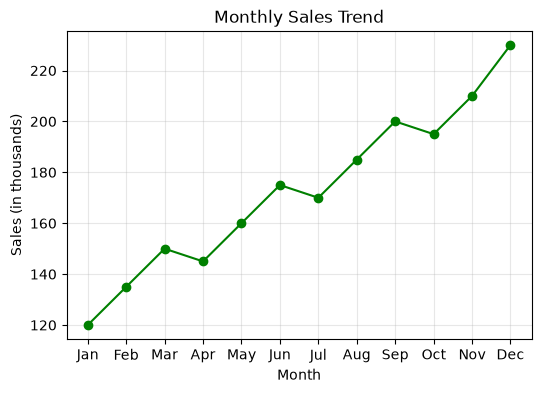

In [8]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
sales = [120, 135, 150, 145, 160, 175, 170, 185, 200, 195, 210, 230]  # in thousands

plt.plot(months, sales, marker="o", color="green")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (in thousands)")
plt.grid(True, alpha=0.3)
plt.show()

#### What the program does
The program plots sales against months in order and joins the points with a line. The circle markers make each individual month's value visible.

### Interpretation
The line goes upward from left to right, which shows a steady growth trend over the year, from 120 in January to 230 in December. There are a few small dips (April, July and October), but the overall direction is still up. A line chart is the right choice here because the months have a natural order and the connecting line helps the eye follow the trend.

#### Advantages
- Best chart for showing trends and changes over time.
- Can show more than one series on the same chart for comparison.

#### Limitations
- Only makes sense when the x-axis has a natural order.
- Too many lines on one chart become hard to read.

## Scatter Plot

### Purpose
A scatter plot shows the relationship between two numeric variables, with each point representing one observation. It shows whether the variables move together, and how strongly.

### When to Use
Use it when you want to check the relationship between two continuous variables, like study hours and marks, or spot outliers and clusters.

### Python Example

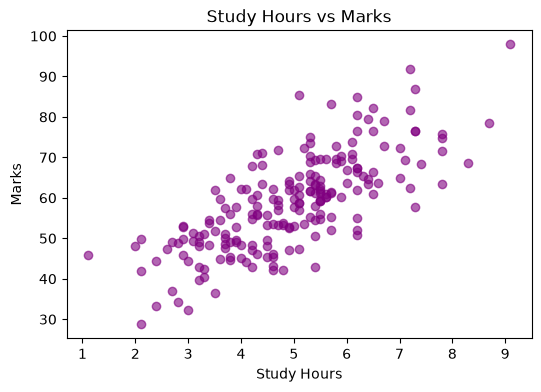

In [9]:
plt.scatter(df["study_hours"], df["marks"], alpha=0.6, color="purple")
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()

#### What the program does
The program places one point for each of the 200 students, with study hours on the x-axis and marks on the y-axis. The `alpha=0.6` makes the points slightly transparent so overlapping points are still visible.

### Interpretation
The points form a cloud that rises from the bottom left to the top right, which means students who study more tend to score higher marks (a positive correlation of about 0.74). The points are not on a perfect line because other factors (the random noise in the data) also affect marks. This is why we see a spread around the general upward trend, not a straight line.

#### Advantages
- Shows the relationship, direction and strength between two variables.
- Helps spot outliers and clusters easily.

#### Limitations
- Only shows two variables at a time.
- With a very large number of points, they overlap and the pattern becomes hard to see.

## Pie Chart

### Purpose
A pie chart shows how a whole is divided into parts, with each slice representing the share of one category.

### When to Use
Use it only when you have a small number of categories (around 5 or fewer) and you want to show proportions of a total, like the share of students in each department.

### Python Example

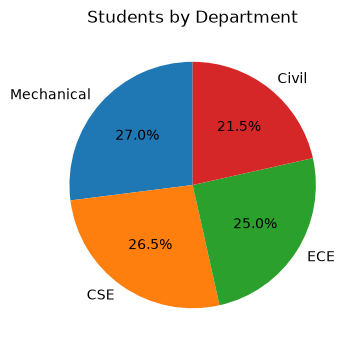

In [10]:
department_counts = df["department"].value_counts()

plt.pie(department_counts.values, labels=department_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Students by Department")
plt.show()

#### What the program does
The program counts how many students are in each department and draws a slice for each one. `autopct` writes the percentage on each slice.

### Interpretation
The four slices are fairly close in size, between about 21% and 27%, because departments were assigned randomly, so students are spread almost evenly. Mechanical and CSE are slightly larger and Civil is the smallest. Since the slices are so similar, it is hard to rank them just by looking, which shows one weakness of pie charts.

#### Advantages
- Quickly shows the share of each part in a whole.
- Easy to understand for non-technical people.

#### Limitations
- Hard to compare slices that are similar in size.
- Becomes unreadable with many categories, and a bar chart is usually better.

## Density Plot

### Purpose
A density plot is a smooth version of a histogram. Instead of bars, it draws a smooth curve that estimates the distribution of the data, so it is easier to compare the shapes of different groups.

### When to Use
Use it when you want to compare the distribution of a variable across groups, like marks of male and female students on the same chart.

### Python Example

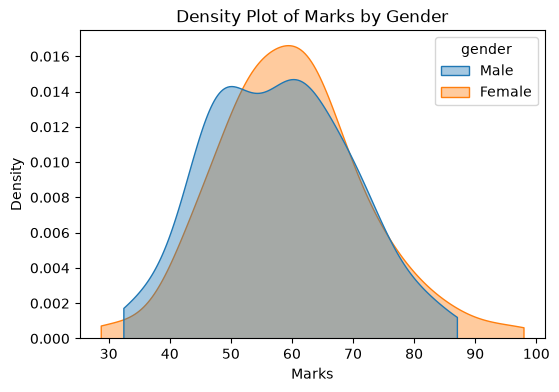

In [11]:
sns.kdeplot(data=df, x="marks", hue="gender", fill=True, alpha=0.4, cut=0)
plt.title("Density Plot of Marks by Gender")
plt.xlabel("Marks")
plt.show()

#### What the program does
The program draws a smooth curve for the marks of each gender and fills the area under it. `hue='gender'` creates separate curves for male and female students on the same axes, and `cut=0` keeps the curves inside the real range of marks, so they do not stretch past 100.

### Interpretation
Both curves are roughly bell-shaped (with small bumps, because each group has only 100 students) and overlap almost completely, with the female curve slightly shifted to the right (average around 60 vs 58 for males). The area under each curve is the same (equal to 1), so the height shows where marks are most concentrated. The heavy overlap tells us the difference between the two groups is small compared to the spread of marks within each group.

#### Advantages
- Smooth shape is easier to compare across groups than overlapping histograms.
- Does not depend on the choice of bin edges.

#### Limitations
- The smoothing can hide small details or create a tail beyond the real data range.
- The y-axis (density) is harder to explain than simple counts.

## Box Plot

### Purpose
A box plot summarizes a distribution using five numbers: minimum, Q1, median, Q3 and maximum, and shows outliers as separate dots. It was introduced in the Dispersion and Outliers notebooks, here it is used to compare groups.

### When to Use
Use it to compare the spread and median of a variable across several categories, and to spot outliers quickly.

### Python Example

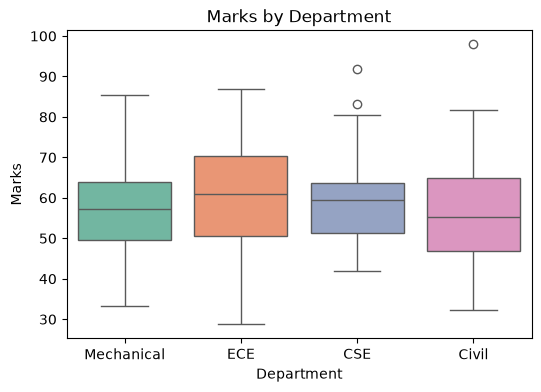

In [12]:
sns.boxplot(data=df, x="department", y="marks", hue="department", palette="Set2", legend=False)
plt.title("Marks by Department")
plt.xlabel("Department")
plt.ylabel("Marks")
plt.show()

#### What the program does
The program draws one box per department. The box covers Q1 to Q3 (the middle 50% of students), the line inside is the median, the whiskers extend to the normal range, and any dots outside the whiskers are outliers.

### Interpretation
All four boxes sit at similar heights with medians between about 55 and 61, and the boxes overlap a lot. This is because department has no real effect on marks in this dataset. The boxes have similar widths, which means the spread of marks is also similar in each department. Only a few dots appear beyond the whiskers (one in Civil and two in CSE), which are students whose marks are unusually high or low compared to their own department.

#### Advantages
- Compares median, spread and outliers across groups in one compact chart.
- Not affected much by extreme values.

#### Limitations
- Does not show the actual shape of the distribution (for example, two peaks would be hidden).
- Can be confusing for people who have not seen box plots before.

## Violin Plot

### Purpose
A violin plot is a mix of a box plot and a density plot. It shows the summary statistics like a box plot, and also the full shape of the distribution on both sides, like a mirrored density curve.

### When to Use
Use it when you want to compare distributions across groups and also care about the shape (for example whether the data has two peaks), which a box plot would hide.

### Python Example

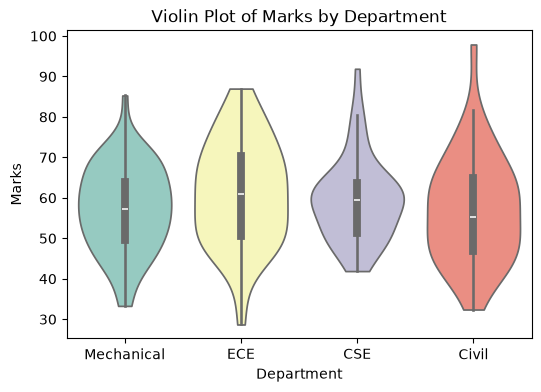

In [13]:
sns.violinplot(data=df, x="department", y="marks", hue="department", palette="Set3", inner="box", cut=0, legend=False)
plt.title("Violin Plot of Marks by Department")
plt.xlabel("Department")
plt.ylabel("Marks")
plt.show()

#### What the program does
The program draws a violin for each department. The width of the violin at any height shows how many students have marks around that value, `inner='box'` places a small box plot inside each violin, and `cut=0` stops each violin at the actual lowest and highest marks, so it does not show marks above 100 that no student has.

### Interpretation
Each violin is widest in the middle (roughly 50 to 65 marks) and thin at the top and bottom, which matches the bell-shaped distribution of marks. The four violins look very similar in shape, which again shows that department does not change how marks are distributed. The small box inside gives the median and quartiles, so we get both the summary and the shape in one chart.

#### Advantages
- Shows both summary statistics and the full distribution shape.
- Can reveal multiple peaks that a box plot would miss.

#### Limitations
- Harder to read for beginners than a box plot.
- With very small groups, the smooth shape can be misleading.

## Pair Plot

### Purpose
A pair plot creates a grid of scatter plots for every pair of numeric variables, and shows the distribution of each variable on the diagonal. It gives a quick overview of all the relationships in a dataset at once.

### When to Use
Use it in the early exploration of a dataset, when you have a handful of numeric features and want to see which ones are related and what each one looks like.

### Python Example

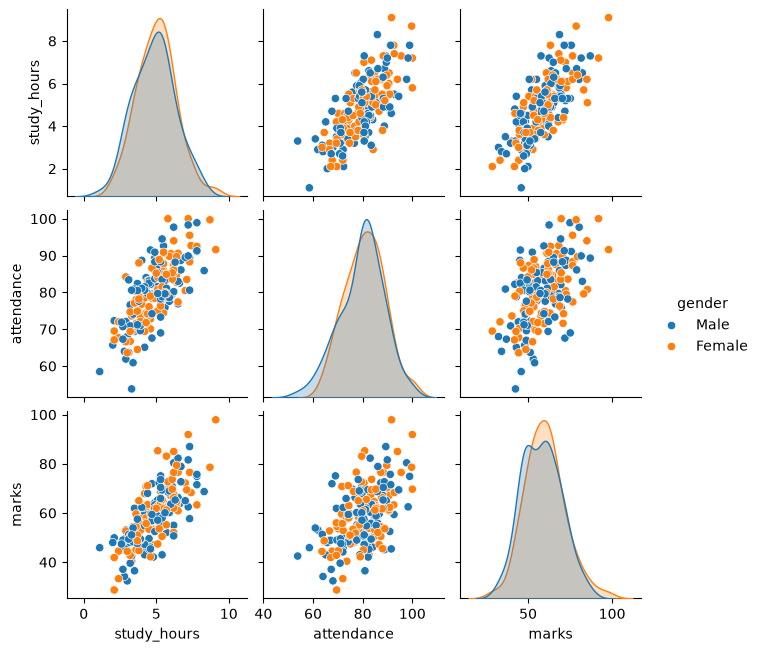

In [14]:
sns.pairplot(df[["study_hours", "attendance", "marks", "gender"]], hue="gender", height=2.2)
plt.show()

#### What the program does
The program picks three numeric columns and draws a scatter plot for each pair, with the diagonal showing the distribution of each column. `hue='gender'` colors the points by gender.

### Interpretation
The scatter plots between study hours and marks show a clear upward pattern, and study hours and attendance also rise together. Attendance and marks show a weaker upward pattern, which matches their lower correlation (about 0.53). The two gender colors are mixed together everywhere, which means gender does not separate the data into different clusters. The diagonal plots are all roughly bell-shaped.

#### Advantages
- Shows many relationships and distributions in a single view.
- Good first step to decide which variables deserve a closer look.

#### Limitations
- Becomes huge and unreadable with many variables.
- Only shows pairwise relationships, not interactions among three or more variables.

## Heatmap

### Purpose
A heatmap shows a matrix of values using color. In statistics it is most commonly used to display a correlation matrix, so strong and weak relationships can be seen at a glance. It was introduced in Notebook 8, here it is used on this dataset.

### When to Use
Use it when you have many numeric variables and want to quickly find which pairs are strongly related, or to check for multicollinearity before building a model.

### Python Example

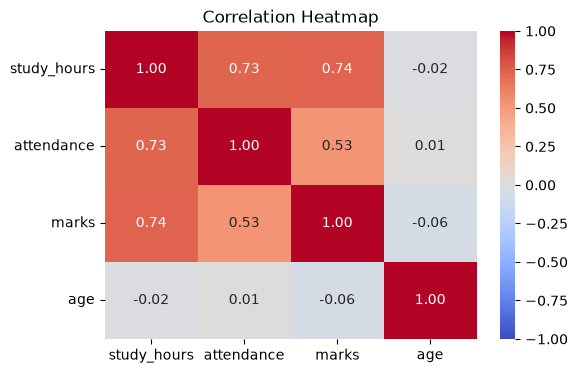

In [15]:
corr = df[["study_hours", "attendance", "marks", "age"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### What the program does
The program calculates the correlation between every pair of numeric columns and shows it as a colored grid. `annot=True` prints the correlation value inside each cell, and `vmin=-1, vmax=1` fixes the color scale so the colors mean the same thing in every chart.

### Interpretation
The diagonal is always 1 (every variable is perfectly correlated with itself). Study hours is strongly related to both marks (about 0.74) and attendance (about 0.73), and attendance and marks are moderately related (about 0.53). Age has a correlation close to 0 with everything, so its cells are almost white. This matches how the dataset was built: marks and attendance depend on study hours, while age is random.

#### Advantages
- Makes patterns in a large correlation matrix visible immediately.
- Fixed color scale makes it easy to compare strong and weak relationships.

#### Limitations
- Only captures linear relationships.
- Does not show whether a relationship is meaningful, and with many variables the grid can still get crowded.

## Interview Questions

**1. What is the difference between a Histogram and a Bar Chart?**</br>

A histogram shows the distribution of one continuous numeric variable by grouping values into bins, so the bars touch each other. A bar chart compares separate categories, so the bars are separate and the order of the categories usually does not matter.

**2. When would you use a Box Plot instead of a Histogram?**</br>

A box plot is better when comparing the spread, median and outliers of several groups side by side. A histogram is better when you want to see the detailed shape of the distribution of a single variable.

**3. What does a Violin Plot show that a Box Plot does not?**</br>

A violin plot shows the full shape of the distribution (for example, if there are two peaks), while a box plot only shows summary statistics like median and quartiles and can hide that shape.

**4. Why is a Pair Plot useful in exploratory data analysis?**</br>

It shows the relationship between every pair of numeric variables and the distribution of each variable in one view, which helps quickly decide which features are related and which deserve a closer look.

**5. What are the disadvantages of a Pie Chart?**</br>

It is hard to compare slices that are similar in size, and it becomes unreadable with many categories. In most cases a bar chart communicates the same information more clearly.

**6. What does a Scatter Plot tell you that a correlation value alone does not?**</br>

A scatter plot shows the actual pattern of the data, such as outliers, clusters, or a curved (non-linear) relationship, which a single correlation number can hide or misrepresent.